# TrafficIQ — Baseline Notebook

**Goal:** Predict traffic demand (0–1) from geographic, road, and weather features.

**Metric:** `score = max(0, 100 × R²)`

---
Steps covered here:
1. Load data
2. Explore & understand
3. Clean missing values
4. Feature engineering
5. Train a baseline model
6. Validate locally
7. Generate submission file

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print('Libraries loaded.')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded.


## 1. Load Data

In [2]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (77299, 11)
Test shape:  (41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## 2. Explore

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 6.5 MB


In [4]:
# Missing value counts
missing = train.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Temperature    2495
Weather         797
RoadType        600
dtype: int64

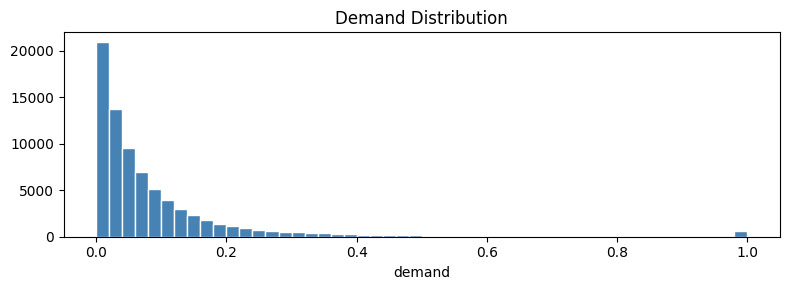

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [5]:
# Target distribution
plt.figure(figsize=(8, 3))
plt.hist(train['demand'], bins=50, color='steelblue', edgecolor='white')
plt.title('Demand Distribution')
plt.xlabel('demand')
plt.tight_layout()
plt.show()

print(train['demand'].describe())

In [6]:
# Categorical value counts
for col in ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']:
    print(f'\n{col}:')
    print(train[col].value_counts(dropna=False))


RoadType:
RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

LargeVehicles:
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

Landmarks:
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

Weather:
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64


## 3. Clean Missing Values

In [7]:
def clean(df):
    df = df.copy()

    # Fill categoricals with mode (most frequent)
    for col in ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']:
        if col in df.columns:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)

    # Fill Temperature with median
    df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())

    return df

train = clean(train)
test  = clean(test)

print('Missing values after cleaning:')
print(train.isnull().sum()[train.isnull().sum() > 0])
print('All clean!' if train.isnull().sum().sum() == 0 else 'Still some missing!')

Missing values after cleaning:
Series([], dtype: int64)
All clean!


## 4. Feature Engineering

In [8]:
def engineer(df):
    df = df.copy()

    # Parse timestamp -> hour, minute, time_of_day (0–96 slots of 15 min)
    time_parts = df['timestamp'].str.split(':', expand=True).astype(int)
    df['hour']        = time_parts[0]
    df['minute']      = time_parts[1]
    df['time_slot']   = df['hour'] * 4 + df['minute'] // 15  # 0–95

    # Cyclical encoding of hour (captures 23->0 continuity)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Day-of-week proxy (day % 7)
    df['day_of_week'] = df['day'] % 7

    # Binary flags
    df['is_large_vehicles'] = (df['LargeVehicles'] == 'Allowed').astype(int)
    df['has_landmark']      = (df['Landmarks'] == 'Yes').astype(int)

    # Encode categoricals
    le = LabelEncoder()
    for col in ['RoadType', 'Weather', 'geohash']:
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))

    return df

train = engineer(train)
test  = engineer(test)

print('New columns added:')
new_cols = ['hour', 'minute', 'time_slot', 'hour_sin', 'hour_cos',
            'day_of_week', 'is_large_vehicles', 'has_landmark',
            'RoadType_enc', 'Weather_enc', 'geohash_enc']
print(train[new_cols].head())

New columns added:
   hour  minute  time_slot  hour_sin  hour_cos  day_of_week  \
0     0       0          0       0.0       1.0            6   
1     0       0          0       0.0       1.0            6   
2     0       0          0       0.0       1.0            6   
3     0       0          0       0.0       1.0            6   
4     0       0          0       0.0       1.0            6   

   is_large_vehicles  has_landmark  RoadType_enc  Weather_enc  geohash_enc  
0                  0             0             1            3            4  
1                  1             1             1            3           25  
2                  0             0             1            3          370  
3                  0             0             1            1          416  
4                  0             0             1            1           22  


## 5. Prepare Feature Matrix

In [9]:
FEATURES = [
    'geohash_enc',
    'day',
    'day_of_week',
    'hour',
    'minute',
    'time_slot',
    'hour_sin',
    'hour_cos',
    'RoadType_enc',
    'NumberofLanes',
    'is_large_vehicles',
    'has_landmark',
    'Temperature',
    'Weather_enc',
]
TARGET = 'demand'

X = train[FEATURES]
y = train[TARGET]
X_test = test[FEATURES]

print(f'X shape:      {X.shape}')
print(f'X_test shape: {X_test.shape}')

X shape:      (77299, 14)
X_test shape: (41778, 14)


## 6. Train — Random Forest Baseline

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')

Train: (61839, 14), Val: (15460, 14)


In [11]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED,
)
model.fit(X_train, y_train)
print('Training done.')

Training done.


## 7. Validate Locally

In [12]:
val_preds = model.predict(X_val)
r2 = r2_score(y_val, val_preds)
score = max(0, 100 * r2)

print(f'R²:    {r2:.4f}')
print(f'Score: {score:.2f}')
print()
print('Rule: only submit if this score is better than our current best.')

R²:    0.9138
Score: 91.38

Rule: only submit if this score is better than our current best.


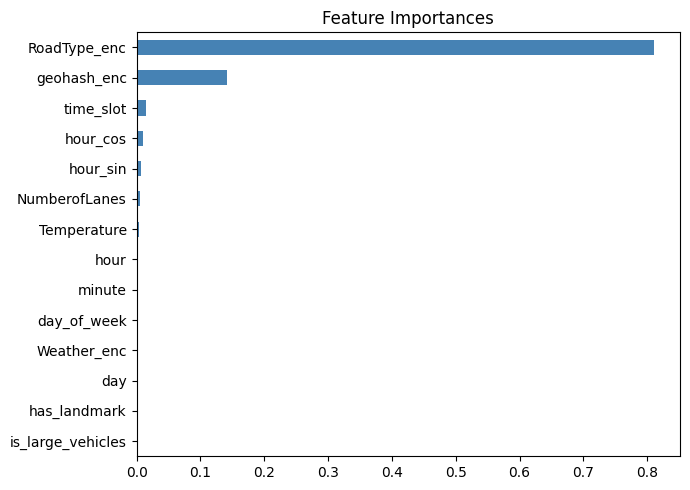

In [13]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

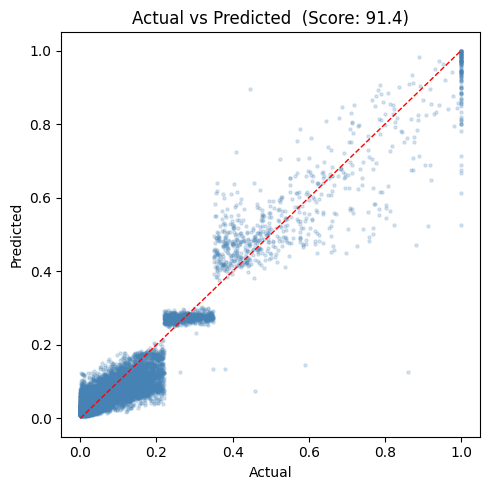

In [14]:
# Predicted vs Actual scatter
plt.figure(figsize=(5, 5))
plt.scatter(y_val, val_preds, alpha=0.2, s=5, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted  (Score: {score:.1f})')
plt.tight_layout()
plt.show()

## 8. Generate Submission

In [16]:
test_preds = model.predict(X_test)

# Clip to valid range
test_preds = np.clip(test_preds, 0.0, 1.0)

submission = pd.DataFrame({
    'Index': test['Index'],
    'demand': test_preds,
})

print(f'Submission shape: {submission.shape}  (expected: 41778 x 2)')
submission.head()

Submission shape: (41778, 2)  (expected: 41778 x 2)


,Index,demand
0,0,0.037614
1,1,0.018477
2,2,0.029883
3,3,0.031774
4,4,0.059147


In [17]:
# Save — edit the filename to reflect your experiment
submission_path = f'../submissions/baseline_rf_score{score:.1f}.csv'
submission.to_csv(submission_path, index=False)
print(f'Saved to: {submission_path}')

Saved to: ../submissions/baseline_rf_score91.4.csv


---
## What's Next?

| Idea | Expected gain |
|------|---------------|
| Switch to LightGBM / XGBoost | Likely +2–5 pts |
| Geohash → lat/lon decode | Spatial signal |
| Lag features (prev time slot demand) | Strong signal if index ordering is temporal |
| Median demand per geohash | Location baseline |
| Tune `n_estimators`, `max_depth` | Marginal |

**Remember: always validate locally before submitting. Only 50 submissions shared across 4 people.**